# Large-Scale Warehouse Simulation

Simulates a **96-aisle warehouse** (4 replicas × 24 aisle types covering all handling/category/size/unit combinations) with **25 pickers** over **1000 batches**.  
Results are persisted to SQLite, outliers are flagged via IQR, and five diagnostic plots are generated.

| Parameter | Value |
|-----------|-------|
| Aisles | 96 (4 × 24 types) |
| SKU catalog | 50 000 |
| Batches | 1 000 |
| Pickers | 25 |
| Batch size | ~5 000 SKUs drawn (≈ 10 % of catalog) |

> **Note**: `affinity=None` is passed to `Batch` so SKU selection uses demand-frequency weights only (no lift-weighted sampling). This keeps each batch under ~2 ms and makes the 1 000-batch run finish in a few minutes.

In [1]:
import os
import random
import sys
import time as _time

# notebook lives in Optimization/
_here = os.getcwd()
_warehouse_path = os.path.normpath(os.path.join(_here, '..', 'Warehouse'))
sys.path.insert(0, _warehouse_path)
sys.path.insert(0, _here)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import gaussian_kde

# Warehouse layer
from Aisle_Storage import Aisle
from Carton import Carton
from Inventory_Builder import Inventory_Builder, InventoryConfig
from Inventory_Management import Inventory_Manager
from Pick import PickConfig, PickSimulation
from Warehouse_Builder import AisleConfig, Warehouse_Builder, WarehouseConfig
from Workload_Builder import Batch, BatchConfig, Task

# Optimization layer
from Picking_Data import (
    BatchStats, TaskStats,
    create_run, init_run_db,
    load_recovered_params,
    save_batch_stats, load_batch_stats,
    save_task_stats,  load_task_stats,
)
from Simulation_Analytics import (
    build_placed_affinity,
    extract_batch_stats, extract_task_stats,
    flag_batch_outliers, flag_task_outliers,
    task_stats_to_aisle_loads, recover_params_to_db,
)
from Workload import WorkloadParams

print('Imports OK')

Imports OK


## Configuration

In [2]:
SEED      = 42
N_BATCHES = 1_000
K_PICKERS = 25
DB_PATH   = os.path.join(_here, 'warehouse_sim.db')

# ── Aisle types: 6 categories × 2 handling × 2 unit types = 24 configs ───────
_CATEGORIES = ['food', 'clothing', 'electronic', 'furniture', 'seasonal', 'chemical']

# Conveyable bins carry small, medium, large items
_CONV_SIZES  = ['small', 'medium', 'large']
_CONV_PROBS  = [0.25, 0.50, 0.25]

# Non-conveyable bins carry medium, large, and extra-large items
_NCONV_SIZES = ['medium', 'large', 'extra_large']
_NCONV_PROBS = [0.20, 0.50, 0.30]

_AISLE_CFGS = []
for _cat in _CATEGORIES:
    _AISLE_CFGS.append(AisleConfig('conveyable',     _cat, 'pallet',    10, 8, _CONV_SIZES,  _CONV_PROBS))
    _AISLE_CFGS.append(AisleConfig('conveyable',     _cat, 'singleton', 10, 8, _CONV_SIZES,  _CONV_PROBS))
for _cat in _CATEGORIES:
    _AISLE_CFGS.append(AisleConfig('non-conveyable', _cat, 'pallet',     8, 8, _NCONV_SIZES, _NCONV_PROBS))
    _AISLE_CFGS.append(AisleConfig('non-conveyable', _cat, 'singleton',  8, 8, _NCONV_SIZES, _NCONV_PROBS))

# 4 replicas of each of the 24 configs = 96 aisles total
WAREHOUSE_CFG = WarehouseConfig(
    total_aisles = 96,
    aisle_splits = [1 / 24] * 24,
    aisle_configs = _AISLE_CFGS,
)

INVENTORY_CFG = InventoryConfig(
    num_skus           = 50_000,
    handling_splits    = [0.5, 0.5],
    category_splits    = [1/6] * 6,
    singleton_fraction = 0.5,
)

# ~5 000 SKUs per batch (10 % of 50 000 catalog)
BATCH_CFG = BatchConfig(
    inventory_size = 50_000,
    mean_fraction  = 0.10,
    std_fraction   = 0.04,
)

PICK_CFG = PickConfig(
    num_pickers      = K_PICKERS,
    x_move_time      = 1.0,
    y_move_time      = 0.5,
    pick_intercept   = 1.0,
    pick_weight_coef = 0.02,
    pick_volume_coef = 1e-4,
    cart_swap_coef   = 5.0,
)
WP = WorkloadParams.from_pick_config(PICK_CFG)

conv_bins  = sum(1 for c in _AISLE_CFGS if c.handling_type == 'conveyable')    * 4 * 10 * 8
nconv_bins = sum(1 for c in _AISLE_CFGS if c.handling_type == 'non-conveyable') * 4 *  8 * 8
print(f'Aisle configs : {len(_AISLE_CFGS)}')
print(f'Total aisles  : {WAREHOUSE_CFG.total_aisles}')
print(f'Est. bins     : {conv_bins + nconv_bins:,}  (conveyable {conv_bins:,} + non-conv {nconv_bins:,})')
print(f'SKU catalog   : {INVENTORY_CFG.num_skus:,}')
print(f'Pickers       : {K_PICKERS}')
print(f'Batches       : {N_BATCHES:,}')

Aisle configs : 24
Total aisles  : 96
Est. bins     : 6,912  (conveyable 3,840 + non-conv 3,072)
SKU catalog   : 50,000
Pickers       : 25
Batches       : 1,000


## Build World

In [3]:
Carton.next_sku    = 1
Aisle.next_aisle_id = 1
random.seed(SEED)

t0 = _time.perf_counter()

print('Building warehouse...', end=' ', flush=True)
warehouse = Warehouse_Builder().from_config(WAREHOUSE_CFG).build()
print(f'{len(warehouse.aisles)} aisles, {len(warehouse.bins):,} bins')

print('Building inventory...', end=' ', flush=True)
inventory = Inventory_Builder().from_config(INVENTORY_CFG).build()
print(f'{len(inventory.cartons):,} cartons')

print('Stocking warehouse... ', end='', flush=True)
manager = Inventory_Manager(warehouse)
manager.enqueue_all(inventory.cartons, quantity=1)
placed = len(manager.unavailable)
print(f'{placed:,} bins filled  ({placed/len(warehouse.bins):.1%} utilisation)')

# Build a sparse affinity matrix covering only placed SKUs.
# max_per_group=300 gives 5 * C(300,2) * 2 ≈ 450 k entries (~50 MB) — fast to
# build and produces non-zero lift_sums for tasks that share two eligible SKUs.
# Batch construction still passes affinity=None so SKU sampling uses fast
# random.sample (demand-frequency weights only, no lift-weighted enumeration).
print('Building placed affinity...', end=' ', flush=True)
PLACED_AFFINITY = build_placed_affinity(warehouse, inventory, max_per_group=300)
n_pairs = len(PLACED_AFFINITY) // 2
print(f'{len(PLACED_AFFINITY):,} entries  ({n_pairs:,} unique pairs)')

print(f'World ready in {_time.perf_counter() - t0:.1f}s')

Building warehouse... 96 aisles, 6,912 bins
Building inventory... 50,000 cartons
Stocking warehouse... 6,912 bins filled  (100.0% utilisation)
Building placed affinity... 448,500 entries  (224,250 unique pairs)
World ready in 2.9s


## Initialise Database

In [4]:
init_run_db(DB_PATH)
RUN_ID = create_run(DB_PATH, 'large_warehouse_1000')
print(f'DB  : {DB_PATH}')
print(f'Run : {RUN_ID}')

DB  : c:\Users\myfir\Code and Repos\Inventory_Location_Optimizer\Optimization\warehouse_sim.db
Run : 2


## Simulation Loop — 1 000 Batches

Each iteration:
1. Draw a random batch from the 50 000-SKU catalog
2. Decompose into per-aisle tasks
3. Run `PickSimulation` with 25 pickers
4. Extract `BatchStats` + `TaskStats` from events
5. Flush to DB every 100 batches

In [5]:
_CHECKPOINT = 100   # flush to DB every N batches

all_batch_stats: list[BatchStats] = []
all_task_stats:  list[TaskStats]  = []
_pending_batch: list[BatchStats]  = []
_pending_task:  list[TaskStats]   = []

t_loop = _time.perf_counter()
skipped = 0

for _i in range(N_BATCHES):
    batch = Batch(BATCH_CFG, inventory, affinity=None)
    tasks = Task.from_batch(batch, warehouse)

    if not tasks:
        skipped += 1
        continue

    events = PickSimulation(tasks, PICK_CFG).run()

    bs = extract_batch_stats(events, batch_id=_i, k_pickers=K_PICKERS, run_id=RUN_ID)
    # PLACED_AFFINITY gives non-zero lift_sums for eligible SKU pairs,
    # enabling meaningful parameter recovery after the loop.
    ts = extract_task_stats(events, tasks, batch_id=_i,
                            affinity=PLACED_AFFINITY, wp=WP, run_id=RUN_ID)

    _pending_batch.append(bs)
    _pending_task.extend(ts)
    all_batch_stats.append(bs)
    all_task_stats.extend(ts)

    if len(_pending_batch) >= _CHECKPOINT:
        save_batch_stats(DB_PATH, RUN_ID, _pending_batch)
        save_task_stats( DB_PATH, RUN_ID, _pending_task)
        elapsed = _time.perf_counter() - t_loop
        rate    = (_i + 1) / elapsed
        print(f'Batch {_i+1:4d}/{N_BATCHES}  '
              f'tasks/batch={len(ts)}  '
              f'items/batch={bs.total_items}  '
              f'duration={bs.duration:.1f}  '
              f'{rate:.1f} batches/s',
              flush=True)
        _pending_batch.clear()
        _pending_task.clear()

# flush remainder
if _pending_batch:
    save_batch_stats(DB_PATH, RUN_ID, _pending_batch)
    save_task_stats( DB_PATH, RUN_ID, _pending_task)

elapsed_total = _time.perf_counter() - t_loop
print(f'\nDone: {N_BATCHES - skipped} batches in {elapsed_total:.1f}s  '
      f'({skipped} skipped — no tasks)',
      flush=True)

Batch  100/1000  tasks/batch=92  items/batch=347  duration=163.0  33.6 batches/s
Batch  200/1000  tasks/batch=96  items/batch=758  duration=288.6  34.1 batches/s
Batch  300/1000  tasks/batch=96  items/batch=715  duration=256.4  35.0 batches/s
Batch  400/1000  tasks/batch=94  items/batch=364  duration=169.1  35.6 batches/s
Batch  502/1000  tasks/batch=96  items/batch=1009  duration=408.9  36.0 batches/s
Batch  603/1000  tasks/batch=96  items/batch=814  duration=319.6  36.6 batches/s
Batch  703/1000  tasks/batch=96  items/batch=826  duration=356.3  36.3 batches/s
Batch  803/1000  tasks/batch=96  items/batch=977  duration=344.3  36.3 batches/s
Batch  903/1000  tasks/batch=94  items/batch=376  duration=204.7  36.5 batches/s

Done: 997 batches in 27.6s  (3 skipped — no tasks)


## Load, Clean, and Summarise

In [6]:
# ── Load from DB ──────────────────────────────────────────────────────────────
bs_raw = load_batch_stats(DB_PATH, RUN_ID)
ts_raw = load_task_stats( DB_PATH, RUN_ID)

# ── Outlier detection (IQR on duration) ───────────────────────────────────────
bs_flagged = flag_batch_outliers(bs_raw, iqr_factor=1.5)
ts_flagged = flag_task_outliers( ts_raw, iqr_factor=1.5)

bs_clean = [s for s in bs_flagged if not s.is_outlier]
ts_clean = [s for s in ts_flagged if not s.is_outlier]

print(f'BatchStats : {len(bs_raw):>6,} total  |  {sum(s.is_outlier for s in bs_flagged):>5,} outliers  |  {len(bs_clean):>6,} clean')
print(f'TaskStats  : {len(ts_raw):>6,} total  |  {sum(s.is_outlier for s in ts_flagged):>5,} outliers  |  {len(ts_clean):>6,} clean')

BatchStats :    997 total  |      4 outliers  |     993 clean
TaskStats  : 92,623 total  |  2,686 outliers  |  89,937 clean


## Summary Statistics Table

In [7]:
def _batch_df(stats: list[BatchStats]) -> pd.DataFrame:
    return pd.DataFrame([
        {
            'batch_id'               : s.batch_id,
            'duration'               : s.duration,
            'num_tasks'              : s.num_tasks,
            'total_items'            : s.total_items,
            'completion_rate'        : s.total_items / s.duration if s.duration > 0 else 0,
            'avg_concurrent_pickers' : s.avg_concurrent_pickers,
            'picking_pct'            : s.picking_pct * 100,
            'traveling_pct'          : s.traveling_pct * 100,
            'is_outlier'             : s.is_outlier,
        }
        for s in stats
    ])

def _task_df(stats: list[TaskStats]) -> pd.DataFrame:
    return pd.DataFrame([
        {
            'batch_id'       : s.batch_id,
            'aisle_id'       : s.aisle_id,
            'picker_id'      : s.picker_id,
            'duration'       : s.duration,
            'W_a'            : s.W_a,
            'lift_sum'       : s.lift_sum,
            'num_bins'       : s.num_bins_visited,
            'total_items'    : s.total_items,
            'is_outlier'     : s.is_outlier,
        }
        for s in stats
    ])

df_batch_all   = _batch_df(bs_flagged)
df_batch_clean = _batch_df(bs_clean)
df_task_all    = _task_df(ts_flagged)
df_task_clean  = _task_df(ts_clean)

# ── Summary table ─────────────────────────────────────────────────────────────
_summary_cols = ['duration', 'num_tasks', 'total_items', 'completion_rate',
                 'avg_concurrent_pickers', 'picking_pct', 'traveling_pct']

summary = (
    df_batch_clean[_summary_cols]
    .agg(['mean', 'median', 'std', 'min', 'max'])
    .round(3)
)
summary.index.name = 'stat'

print('=== Clean Batch Statistics (n =', len(bs_clean), ')===')
display(summary)

_task_summary_cols = ['duration', 'W_a', 'num_bins', 'total_items']
task_summary = (
    df_task_clean[_task_summary_cols]
    .agg(['mean', 'median', 'std', 'min', 'max'])
    .round(3)
)
task_summary.index.name = 'stat'

print('\n=== Clean Task Statistics (n =', len(ts_clean), ')===')
display(task_summary)

=== Clean Batch Statistics (n = 993 )===


,duration,num_tasks,total_items,completion_rate,avg_concurrent_pickers,picking_pct,traveling_pct
stat,,,,,,,
mean,269.724,93.081,657.598,2.359,8.426,54.299,45.701
median,274.023,96.000,662.000,2.413,8.675,55.063,44.937
std,95.356,9.868,277.585,0.361,1.442,5.465,5.465
min,17.825,7.000,7.000,0.393,1.734,29.059,34.518
max,514.432,96.000,1522.000,3.123,11.314,65.482,70.941



=== Clean Task Statistics (n = 89937 )===


,duration,W_a,num_bins,total_items
stat,,,,
mean,42.922,35.145,6.854,6.854
median,37.464,29.845,7.000,7.000
std,23.778,22.181,3.535,3.535
min,1.231,1.082,1.000,1.000
max,109.699,109.528,26.000,26.000


## Plot 1 — Batch Completion Time Distribution

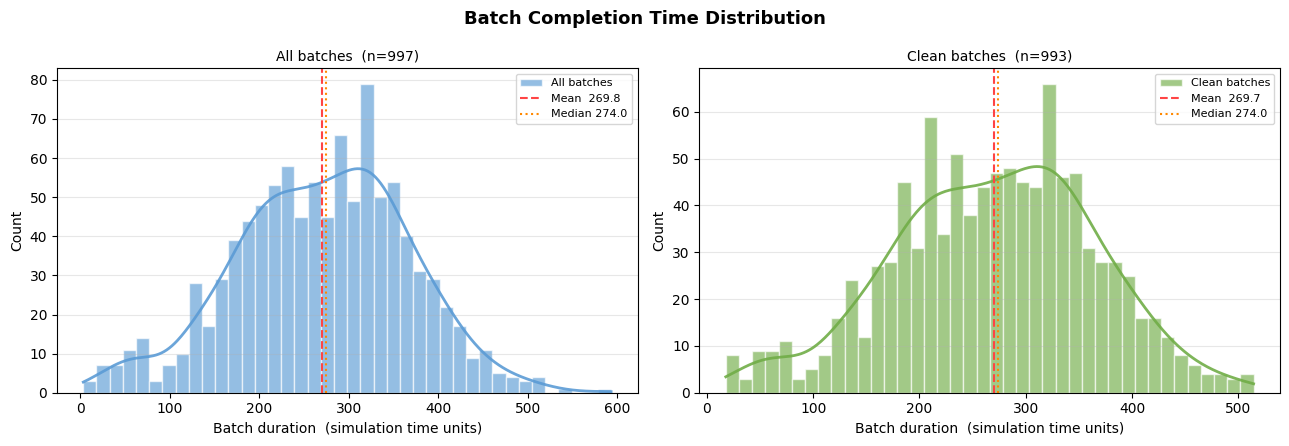

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
fig.suptitle('Batch Completion Time Distribution', fontsize=13, fontweight='bold')

for ax, data, label, color in [
    (axes[0], df_batch_all['duration'].values,   'All batches',   '#5b9bd5'),
    (axes[1], df_batch_clean['duration'].values,  'Clean batches', '#70ad47'),
]:
    if len(data) < 2:
        continue
    ax.hist(data, bins=40, color=color, alpha=0.65, edgecolor='white', label=label)

    # KDE overlay
    kde  = gaussian_kde(data, bw_method='silverman')
    xs   = np.linspace(data.min(), data.max(), 400)
    ax.plot(xs, kde(xs) * len(data) * (data.max() - data.min()) / 40,
            color=color, lw=2, alpha=0.9)

    mu  = float(np.mean(data))
    med = float(np.median(data))
    ax.axvline(mu,  color='#ff4444', lw=1.5, linestyle='--', label=f'Mean  {mu:.1f}')
    ax.axvline(med, color='#ff8800', lw=1.5, linestyle=':',  label=f'Median {med:.1f}')

    ax.set_xlabel('Batch duration  (simulation time units)', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title(f'{label}  (n={len(data):,})', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
plt.show()

## Plot 2 — Task Completion Time Distribution

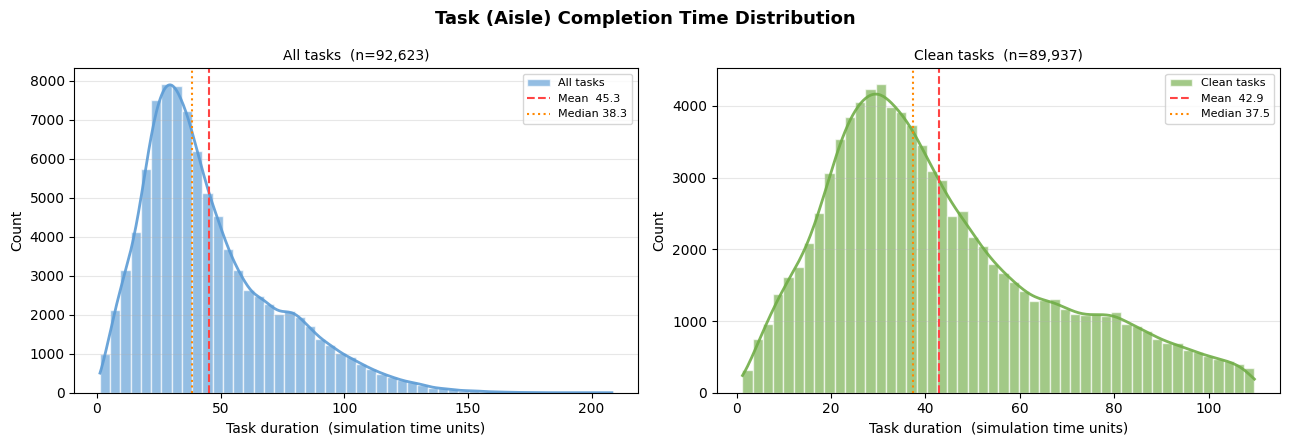

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Task (Aisle) Completion Time Distribution', fontsize=13, fontweight='bold')

for ax, data, label, color in [
    (axes[0], df_task_all['duration'].values,   'All tasks',   '#5b9bd5'),
    (axes[1], df_task_clean['duration'].values,  'Clean tasks', '#70ad47'),
]:
    if len(data) < 2:
        continue
    ax.hist(data, bins=50, color=color, alpha=0.65, edgecolor='white', label=label)

    kde = gaussian_kde(data, bw_method='silverman')
    xs  = np.linspace(data.min(), data.max(), 400)
    ax.plot(xs, kde(xs) * len(data) * (data.max() - data.min()) / 50,
            color=color, lw=2, alpha=0.9)

    mu  = float(np.mean(data))
    med = float(np.median(data))
    ax.axvline(mu,  color='#ff4444', lw=1.5, linestyle='--', label=f'Mean  {mu:.1f}')
    ax.axvline(med, color='#ff8800', lw=1.5, linestyle=':',  label=f'Median {med:.1f}')

    ax.set_xlabel('Task duration  (simulation time units)', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title(f'{label}  (n={len(data):,})', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
plt.show()

## Plot 3 — Batch Completion Rate (Rolling Average)

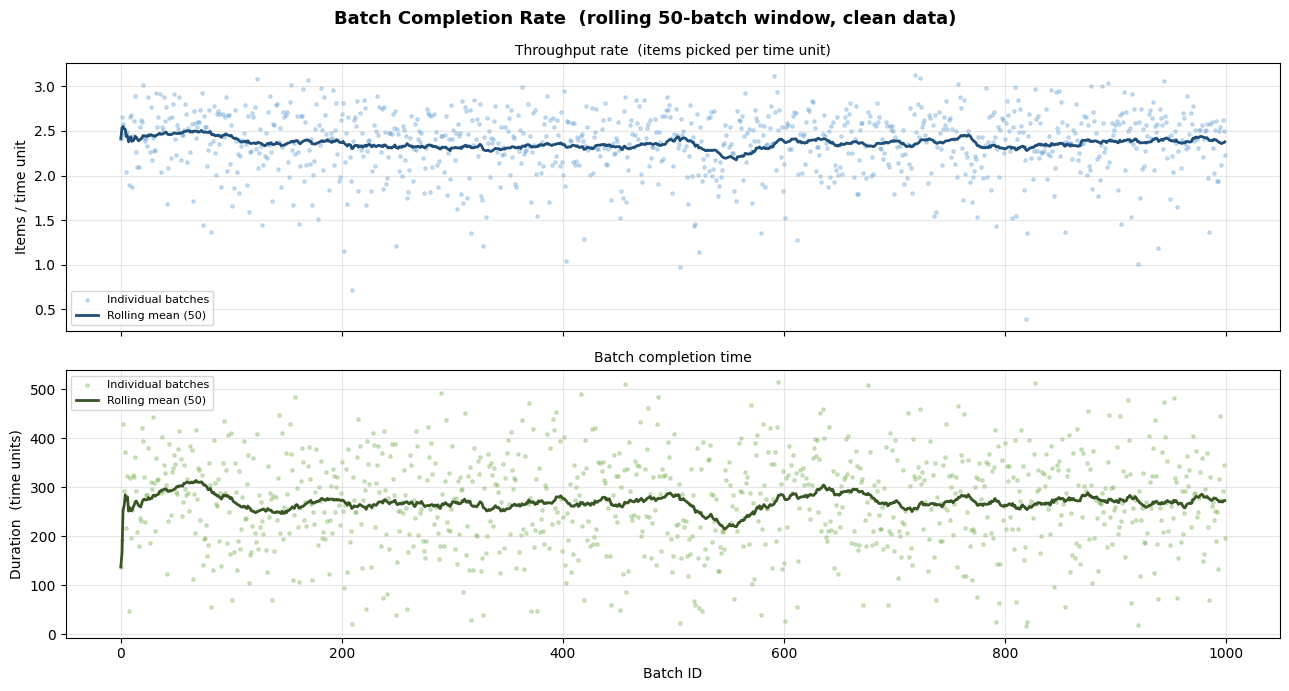

In [10]:
_WINDOW = 50  # rolling window size

# Sort clean batches by batch_id for a meaningful rolling view
df_sorted = df_batch_clean.sort_values('batch_id').reset_index(drop=True)

df_sorted['rate_roll']  = df_sorted['completion_rate'].rolling(_WINDOW, min_periods=1).mean()
df_sorted['items_roll'] = df_sorted['total_items'].rolling(_WINDOW, min_periods=1).mean()
df_sorted['dur_roll']   = df_sorted['duration'].rolling(_WINDOW, min_periods=1).mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
fig.suptitle(f'Batch Completion Rate  (rolling {_WINDOW}-batch window, clean data)',
             fontsize=13, fontweight='bold')

# Panel 1: items-per-time-unit
ax1.scatter(df_sorted['batch_id'], df_sorted['completion_rate'],
            s=6, alpha=0.3, color='#5b9bd5', label='Individual batches')
ax1.plot(df_sorted['batch_id'], df_sorted['rate_roll'],
         color='#1f4e79', lw=2, label=f'Rolling mean ({_WINDOW})')
ax1.set_ylabel('Items / time unit', fontsize=10)
ax1.set_title('Throughput rate  (items picked per time unit)', fontsize=10)
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# Panel 2: batch duration
ax2.scatter(df_sorted['batch_id'], df_sorted['duration'],
            s=6, alpha=0.3, color='#70ad47', label='Individual batches')
ax2.plot(df_sorted['batch_id'], df_sorted['dur_roll'],
         color='#375623', lw=2, label=f'Rolling mean ({_WINDOW})')
ax2.set_xlabel('Batch ID', fontsize=10)
ax2.set_ylabel('Duration  (time units)', fontsize=10)
ax2.set_title('Batch completion time', fontsize=10)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

fig.tight_layout()
plt.show()

## Plot 4 — Picker Concurrency Distribution

Shows how many pickers are simultaneously in the **picking** state (not traveling, swapping carts, or idle) at any given moment during a batch.

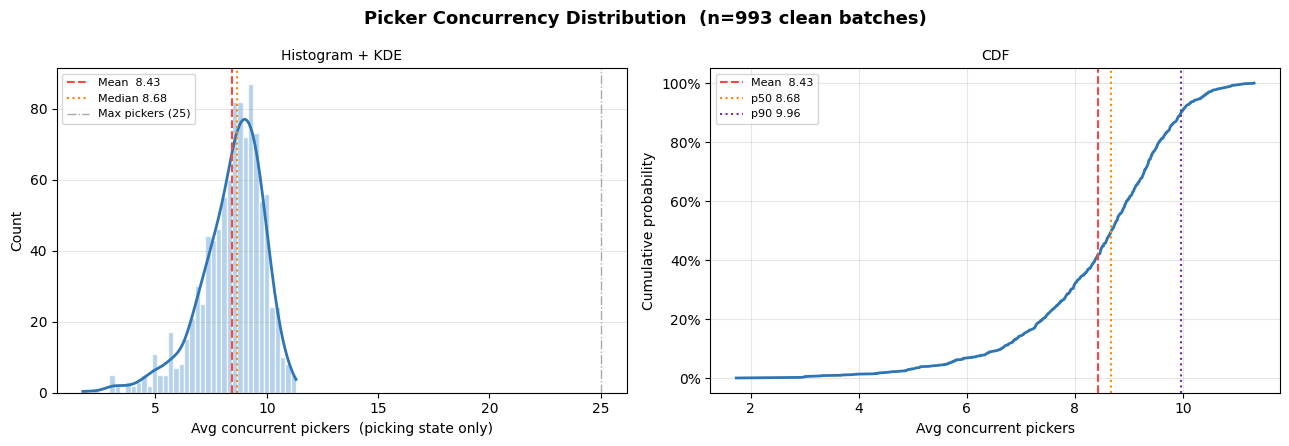

In [11]:
conc = df_batch_clean['avg_concurrent_pickers'].values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle(f'Picker Concurrency Distribution  (n={len(conc):,} clean batches)',
             fontsize=13, fontweight='bold')

# Histogram + KDE
ax1.hist(conc, bins=40, color='#9dc3e6', alpha=0.75, edgecolor='white')
if len(conc) > 1:
    kde = gaussian_kde(conc, bw_method='silverman')
    xs  = np.linspace(conc.min(), conc.max(), 400)
    ax1.plot(xs, kde(xs) * len(conc) * (conc.max() - conc.min()) / 40,
             color='#2e75b6', lw=2)
ax1.axvline(float(np.mean(conc)),   color='#ff4444', lw=1.5, linestyle='--',
             label=f'Mean  {np.mean(conc):.2f}')
ax1.axvline(float(np.median(conc)), color='#ff8800', lw=1.5, linestyle=':',
             label=f'Median {np.median(conc):.2f}')
ax1.axvline(K_PICKERS, color='#a9a9a9', lw=1.0, linestyle='-.',
             label=f'Max pickers ({K_PICKERS})')
ax1.set_xlabel('Avg concurrent pickers  (picking state only)', fontsize=10)
ax1.set_ylabel('Count', fontsize=10)
ax1.set_title('Histogram + KDE', fontsize=10)
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.3)

# CDF
xs_sorted = np.sort(conc)
cdf = np.arange(1, len(xs_sorted) + 1) / len(xs_sorted)
ax2.plot(xs_sorted, cdf, color='#2e75b6', lw=2)
ax2.axvline(float(np.mean(conc)),   color='#ff4444', lw=1.5, linestyle='--',
             label=f'Mean  {np.mean(conc):.2f}')
ax2.axvline(float(np.percentile(conc, 50)), color='#ff8800', lw=1.5, linestyle=':',
             label=f'p50 {np.percentile(conc,50):.2f}')
ax2.axvline(float(np.percentile(conc, 90)), color='#7030a0', lw=1.5, linestyle=':',
             label=f'p90 {np.percentile(conc,90):.2f}')
ax2.set_xlabel('Avg concurrent pickers', fontsize=10)
ax2.set_ylabel('Cumulative probability', fontsize=10)
ax2.set_title('CDF', fontsize=10)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))

fig.tight_layout()
plt.show()

## Plot 5 — Picker Utilisation Breakdown

C:\Users\myfir\AppData\Local\Temp\ipykernel_40972\3443662787.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(


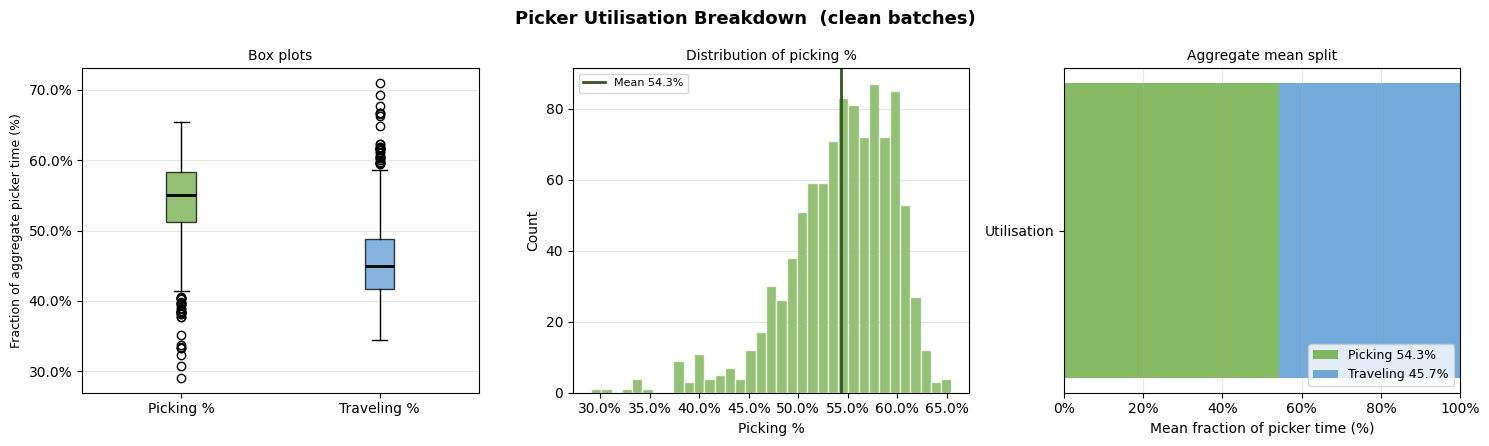

In [12]:
pick_pct = df_batch_clean['picking_pct'].values
trav_pct = df_batch_clean['traveling_pct'].values

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Picker Utilisation Breakdown  (clean batches)', fontsize=13, fontweight='bold')

# ── Boxplot side-by-side ──────────────────────────────────────────────────────
bp = axes[0].boxplot(
    [pick_pct, trav_pct],
    labels=['Picking %', 'Traveling %'],
    patch_artist=True,
    medianprops=dict(color='black', lw=2),
)
for patch, color in zip(bp['boxes'], ['#70ad47', '#5b9bd5']):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[0].set_ylabel('Fraction of aggregate picker time (%)', fontsize=9)
axes[0].set_title('Box plots', fontsize=10)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))
axes[0].grid(axis='y', alpha=0.3)

# ── Histogram: picking % ──────────────────────────────────────────────────────
axes[1].hist(pick_pct, bins=35, color='#70ad47', alpha=0.75, edgecolor='white')
axes[1].axvline(float(np.mean(pick_pct)), color='#375623', lw=2,
                 label=f'Mean {np.mean(pick_pct):.1f}%')
axes[1].set_xlabel('Picking %', fontsize=10)
axes[1].set_ylabel('Count', fontsize=10)
axes[1].set_title('Distribution of picking %', fontsize=10)
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', alpha=0.3)

# ── Stacked aggregate bar ─────────────────────────────────────────────────────
means = [float(np.mean(pick_pct)), float(np.mean(trav_pct))]
axes[2].barh(['Utilisation'], [means[0]], color='#70ad47', alpha=0.85, label=f'Picking {means[0]:.1f}%')
axes[2].barh(['Utilisation'], [means[1]], left=[means[0]], color='#5b9bd5', alpha=0.85,
              label=f'Traveling {means[1]:.1f}%')
axes[2].set_xlim(0, 100)
axes[2].set_xlabel('Mean fraction of picker time (%)', fontsize=10)
axes[2].set_title('Aggregate mean split', fontsize=10)
axes[2].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))
axes[2].legend(fontsize=9, loc='lower right')
axes[2].grid(axis='x', alpha=0.3)

fig.tight_layout()
plt.show()

## Bonus: Per-Aisle Heatmap (Duration vs Aisle ID)

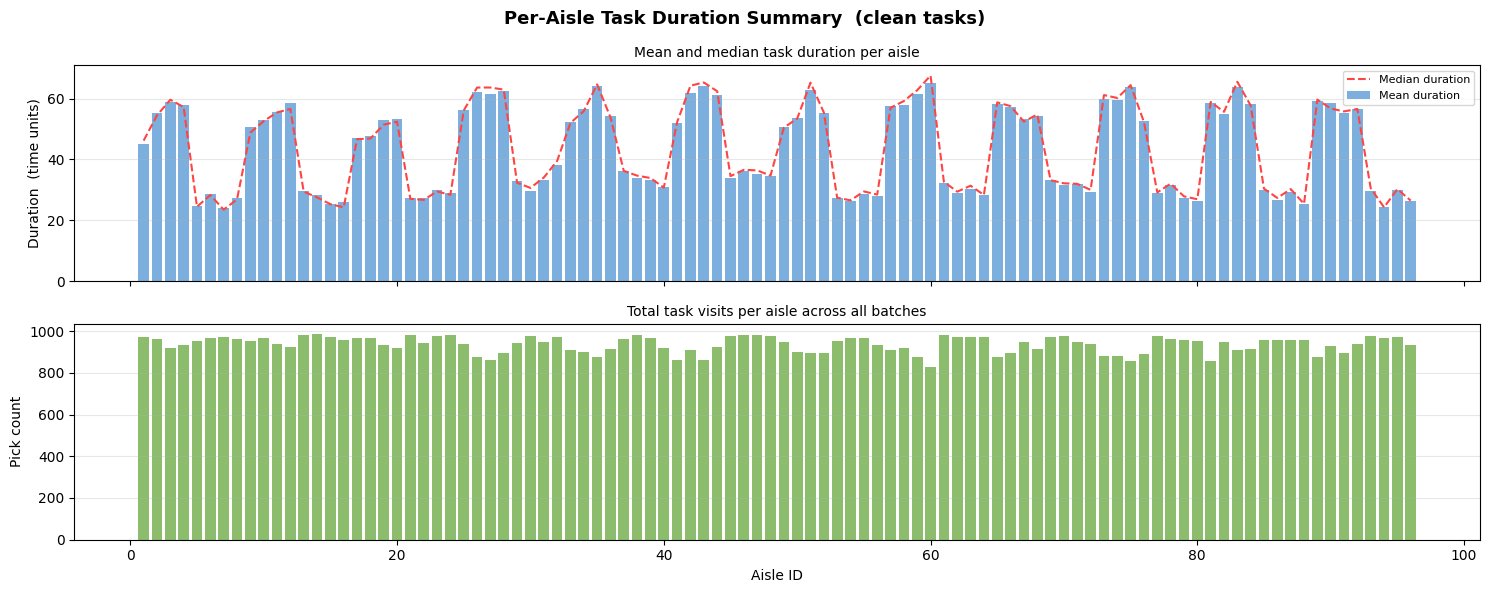

In [13]:
aisle_dur = (
    df_task_clean
    .groupby('aisle_id')['duration']
    .agg(['mean', 'median', 'count'])
    .rename(columns={'mean': 'mean_dur', 'median': 'median_dur', 'count': 'n_picks'})
    .reset_index()
    .sort_values('aisle_id')
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
fig.suptitle('Per-Aisle Task Duration Summary  (clean tasks)', fontsize=13, fontweight='bold')

ax1.bar(aisle_dur['aisle_id'], aisle_dur['mean_dur'], color='#5b9bd5', alpha=0.8, label='Mean duration')
ax1.plot(aisle_dur['aisle_id'], aisle_dur['median_dur'], color='#ff4444', lw=1.5,
         linestyle='--', label='Median duration')
ax1.set_ylabel('Duration  (time units)', fontsize=10)
ax1.set_title('Mean and median task duration per aisle', fontsize=10)
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.3)

ax2.bar(aisle_dur['aisle_id'], aisle_dur['n_picks'], color='#70ad47', alpha=0.8)
ax2.set_xlabel('Aisle ID', fontsize=10)
ax2.set_ylabel('Pick count', fontsize=10)
ax2.set_title('Total task visits per aisle across all batches', fontsize=10)
ax2.grid(axis='y', alpha=0.3)

fig.tight_layout()
plt.show()

## Parameter Recovery — L_a = W_a + λ*(W_a/k)^γ · SUM_lift

Convert the `TaskStats` records (which carry `W_a`, `lift_sum`, and simulation `duration`) into
`AisleLoadRecord` objects, then recover `LoadParams` (λ, γ) via log-linear OLS after IQR
outlier cleaning.  Results are written to the **`aisle_loads`** and **`recovered_params`** tables
in the same SQLite database.

> **Prerequisite**: cells above must have run with `PLACED_AFFINITY` active so that tasks
> contain non-zero `lift_sum` values.  Tasks with `lift_sum = 0` are automatically excluded
> from the OLS fit (they still contribute to RMSE reporting).

In [ ]:
JSON_PATH = os.path.join(_here, 'recovered_params.json')

# ── Convert TaskStats → AisleLoadRecords ──────────────────────────────────────
# All clean task stats become observations; outlier flag is re-derived inside
# recover_params_to_db via IQR on the load residual.
aisle_load_records = task_stats_to_aisle_loads(all_task_stats, run_id=RUN_ID)

n_with_lift = sum(1 for r in aisle_load_records if r.lift_sum > 0)
print(f'AisleLoadRecords  : {len(aisle_load_records):,} total')
print(f'  lift_sum > 0    : {n_with_lift:,}  ({n_with_lift/max(len(aisle_load_records),1):.1%})')
print(f'  lift_sum = 0    : {len(aisle_load_records)-n_with_lift:,}  (excluded from OLS fit)')
print()

# ── Run recovery pipeline and persist to DB ────────────────────────────────────
# k_per_task=1: each aisle task is worked by exactly one picker in this
# simulation.  Do NOT pass the total fleet size (K_PICKERS) here — that
# compresses W_a/k by 25× and produces biased λ/γ estimates.
print('=== Recovery pipeline ===')
rp = recover_params_to_db(
    db_path    = DB_PATH,
    run_id     = RUN_ID,
    records    = aisle_load_records,
    k_per_task = 1,
    json_path  = JSON_PATH,
    do_plot    = False,   # set True to show the W_a vs L_a scatter inline
)

=== Recovered Load Parameters ===
  λ  (lambda)  : 0.660300
  γ  (gamma)   : -0.135628
  k  (pickers) : 25

=== Fit Quality ===
  RMSE (raw fit)   : 8.7384
  RMSE (clean fit) : 8.6929
  Improvement      : 0.5%

=== Coverage ===
  Observations (total) : 92,623
  Observations (clean) : 92,420
  Outliers removed     : 203  (0.2%)

  Recovered at: 2026-05-28T07:59:28.084313+00:00
  JSON export : c:\Users\myfir\Code and Repos\Inventory_Location_Optimizer\Optimization\recovered_params.json


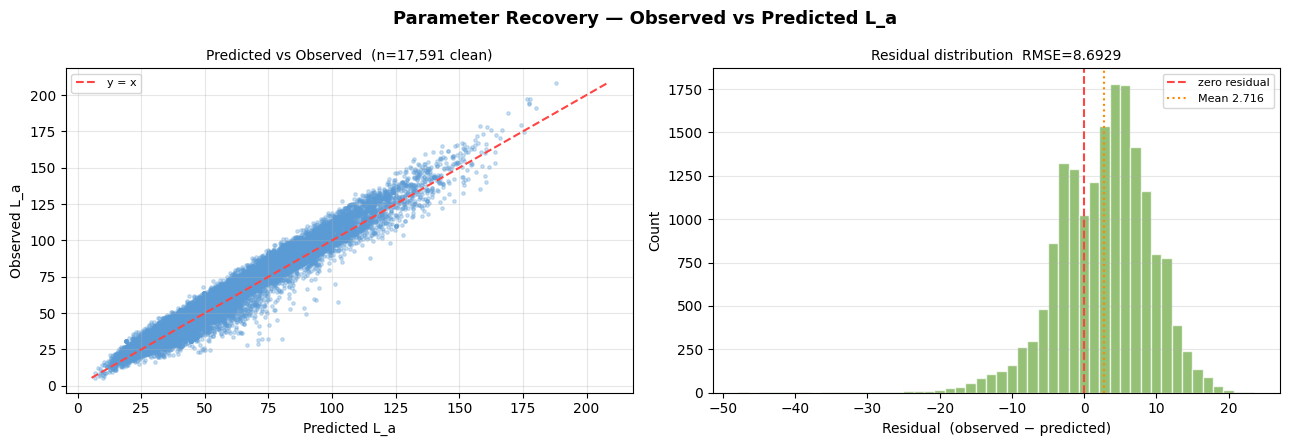

In [15]:
# ── Load recovered parameters from DB and display ─────────────────────────────
rp_loaded = load_recovered_params(DB_PATH, RUN_ID)

if rp_loaded is None:
    print('No recovered parameters found — re-run the recovery cell above.')
else:
    print('=== Recovered Load Parameters ===')
    print(f'  λ  (lambda)  : {rp_loaded.lambda_:.6f}')
    print(f'  γ  (gamma)   : {rp_loaded.gamma:.6f}')
    print(f'  k  (pickers) : {rp_loaded.k:.0f}')
    print()
    print('=== Fit Quality ===')
    print(f'  RMSE (raw fit)   : {rp_loaded.rmse_raw:.4f}')
    print(f'  RMSE (clean fit) : {rp_loaded.rmse_clean:.4f}')
    print(f'  Improvement      : {(rp_loaded.rmse_raw - rp_loaded.rmse_clean) / rp_loaded.rmse_raw * 100:.1f}%')
    print()
    print('=== Coverage ===')
    print(f'  Observations (total) : {rp_loaded.n_samples:,}')
    print(f'  Observations (clean) : {rp_loaded.n_clean:,}')
    n_out = rp_loaded.n_samples - rp_loaded.n_clean
    print(f'  Outliers removed     : {n_out:,}  ({n_out/max(rp_loaded.n_samples,1):.1%})')
    print()
    print(f'  Recovered at: {rp_loaded.timestamp}')
    if os.path.exists(JSON_PATH):
        print(f'  JSON export : {JSON_PATH}')

    # ── Inline W_a vs L_a scatter (clean observations only) ──────────────────
    al_records = [r for r in aisle_load_records if r.lift_sum > 0 and not r.is_outlier]
    if al_records:
        W = np.array([r.W_a      for r in al_records])
        S = np.array([r.lift_sum for r in al_records])
        L = np.array([r.observed_L_a for r in al_records])

        k  = rp_loaded.k
        lm = rp_loaded.lambda_
        gm = rp_loaded.gamma
        L_pred = W + lm * (W / k) ** gm * S

        fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
        fig.suptitle('Parameter Recovery — Observed vs Predicted L_a', fontsize=13, fontweight='bold')

        # Scatter: observed vs predicted
        ax = axes[0]
        ax.scatter(L_pred, L, s=6, alpha=0.3, color='#5b9bd5')
        lims = [min(L_pred.min(), L.min()), max(L_pred.max(), L.max())]
        ax.plot(lims, lims, color='#ff4444', lw=1.5, linestyle='--', label='y = x')
        ax.set_xlabel('Predicted L_a', fontsize=10)
        ax.set_ylabel('Observed L_a', fontsize=10)
        ax.set_title(f'Predicted vs Observed  (n={len(L):,} clean)', fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

        # Residuals
        ax = axes[1]
        resid = L - L_pred
        ax.hist(resid, bins=50, color='#70ad47', alpha=0.75, edgecolor='white')
        ax.axvline(0, color='#ff4444', lw=1.5, linestyle='--', label='zero residual')
        ax.axvline(float(np.mean(resid)), color='#ff8800', lw=1.5, linestyle=':',
                   label=f'Mean {np.mean(resid):.3f}')
        ax.set_xlabel('Residual  (observed − predicted)', fontsize=10)
        ax.set_ylabel('Count', fontsize=10)
        ax.set_title(f'Residual distribution  RMSE={rp_loaded.rmse_clean:.4f}', fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3)

        fig.tight_layout()
        plt.show()